### Init

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import rfft, irfft
from matplotlib.animation import FuncAnimation, PillowWriter
import fhd
import importlib
import time
from collections import defaultdict

importlib.reload(fhd) 

<module 'fhd' from 'c:\\Users\\rmosk\\Dropbox\\Rinske\\Computational Science\\A Scriptie\\fluctuating_hydro\\fhd\\__init__.py'>

In [2]:
title_size = 16
ax_size = 14

In [3]:
N = (2**6, 2**6)
L = (50,50)
Lx, Ly = L
sim_2d = fhd.fhd_2d_3species(L,N, bc= 'Neumann', fft=False)

ns = sim_2d.nspecies

In [4]:
x = sim_2d.x
y = sim_2d.y

xx, yy = np.meshgrid(x, y, indexing='ij')
phi_init = np.zeros((ns,)+ sim_2d.N)
phi0 = 0.3

pert_amp = 0.0
phi_init[0] = phi0 + pert_amp * np.cos(2*np.pi*(xx) / Lx * 2)  + pert_amp * np.cos(2*np.pi*(yy) / Lx * 2)  + 0.05 * np.random.normal(size=sim_2d.N) 
phi_init[1] = phi0 + pert_amp * np.sin(2*np.pi*(xx) / Lx * 2) + pert_amp * np.sin(2*np.pi*(yy) / Lx * 2) + 0.05 * np.random.normal(size=sim_2d.N) 
phi_init[2] = phi0 + pert_amp * np.cos((2*np.pi*(xx) / Lx * 2) + np.pi/2) + 0.05 * np.random.normal(size=sim_2d.N)

# Initial condition

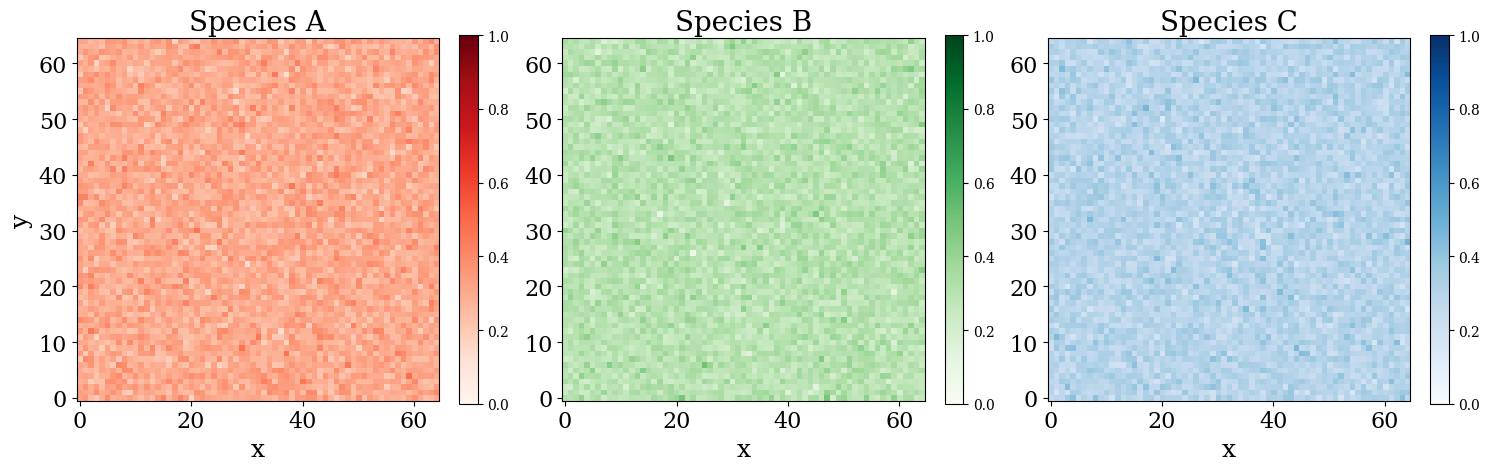

In [5]:
param_init = {
    'D': np.array([1.0, 1.0, 1.0]),
    'Gamma': np.array([1.0, 1.0, 1.0]),
    'kappa': np.array([[0.0, -1.0, 1.0], [1.0, 0.0, -1.0], [-1.0, 1.0, 0.0]]),
    'noise_amp': np.array([0.01, 0.01, 0.01])
}
sim_2d.phi_plot(phi_init, param_init, model = "Vitelli", plot_2=False, plot_3=False)

## Phase space linear utility

## Kappas

In [6]:
D = 0.1*np.ones(ns) # Schelling diffusion coefficient
Gamma = np.eye(ns) # Utility nabla^3 term coefficient
nu = np.zeros((ns,ns,ns))

In [7]:
kappa_segregated = np.array([
    [1, -1, -1],
    [-1, 1, -1],
    [-1, -1, 1]
])

kappa_mixed = np.array([
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0]
])

kappa_dynamic = np.array([
    [1, 0.5, 0],   # Agent 1 loves Agent 2, dislikes Agent 3
    [-1, 1, 0.5],  # Agent 2 is neutral toward Agent 1 and 3
    [-1, -1, 1]  # Agent 3 dislikes Agent 1, neutral toward Agent 2
])

kappa_1segregated_2mixed = np.array([
    [1, -1, -1],    # Agent 1 dislikes Agents 2 and 3
    [-1, 0, 0],   # Agent 2 is neutral toward Agent 3
    [-1, 0, 0]    # Agent 3 is neutral toward Agent 2
])

kappa_1segregated_2dynamic = np.array([
    [1, -1, -1],    # Agent 1 dislikes Agents 2 and 3
    [-1, 1, 1],     # Agent 2 loves Agent 3
    [-1, -1, 1]    # Agent 3 dislikes Agent 2
])

kappas = [kappa_segregated, kappa_mixed, kappa_dynamic, kappa_1segregated_2mixed, kappa_1segregated_2dynamic]
kappa_names = ["Segregated", "Mixed", "Dynamic", "1 Segregated, 2 Mixed", "1 Segregated, 2 Dynamic"]

## Diffusion

In [ ]:
Gamma = np.eye(ns) # Utility nabla^3 term coefficient
nu = np.zeros((ns,ns,ns))
Ds = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

dt = 0.005
# nsteps = 100000
# nsteps = 5000
noise = 0
frames = 100
phis_Dif = defaultdict(dict)

tot = len(kappas) * len(Ds)
sim_count = 0

for i, kappa in enumerate(kappas):
    for D in Ds:
        param_kappa = {'D': D*np.ones(ns), 'kappa': kappa, 'Gamma': Gamma, 'nu': nu}
        st = time.time()
        phi_run = sim_2d.run_until_converged(phi_init, param_kappa, dt, noise, frames, model = "Vitelli", verbatum=False)
        et = time.time()
        print(f"Simulation {kappa_names[i]}, D = {D}: ran in t = {et-st:.6f} seconds ({sim_count}/{tot})")
        phis_Dif[kappa_names[i]][D] = phi_run[:, -1]
        sim_count += 1
    print(f"Completed simulations for {kappa_names[i]}")

Simulation Segregated, D = 0: ran in t = 32.771612 seconds (0/55)
Simulation Segregated, D = 0.05: ran in t = 36.476937 seconds (1/55)
Simulation Segregated, D = 0.1: ran in t = 42.363783 seconds (2/55)
Simulation Segregated, D = 0.15: ran in t = 51.515513 seconds (3/55)
Simulation Segregated, D = 0.2: ran in t = 62.528074 seconds (4/55)
Simulation Segregated, D = 0.25: ran in t = 88.997513 seconds (5/55)
Simulation Segregated, D = 0.3: ran in t = 122.387628 seconds (6/55)
Simulation Segregated, D = 0.35: ran in t = 195.619688 seconds (7/55)
Simulation Segregated, D = 0.4: ran in t = 22.991700 seconds (8/55)
Simulation Segregated, D = 0.45: ran in t = 40.405747 seconds (9/55)
Simulation Segregated, D = 0.5: ran in t = 95.648331 seconds (10/55)
Completed simulations for Segregated
Simulation Mixed, D = 0: ran in t = 21.689073 seconds (11/55)
Simulation Mixed, D = 0.05: ran in t = 105.094051 seconds (12/55)
Simulation Mixed, D = 0.1: ran in t = 111.992680 seconds (13/55)
Simulation Mixed

### Snapshots

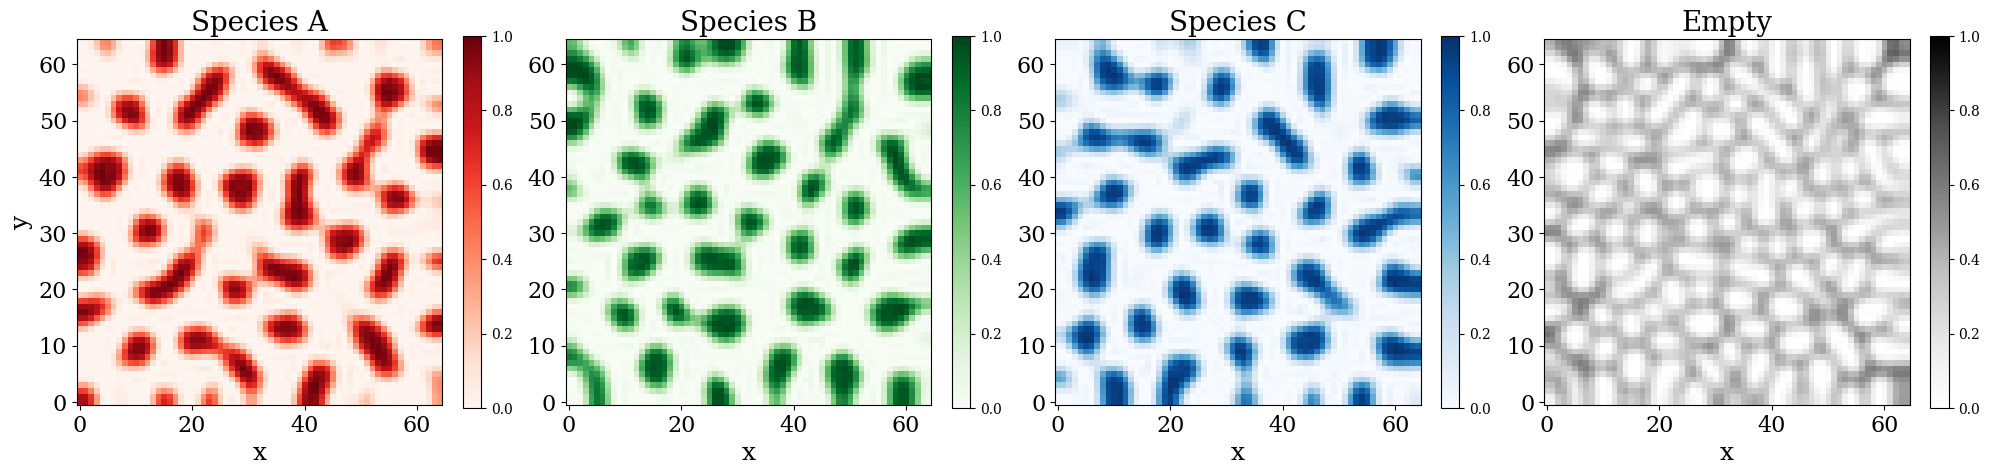

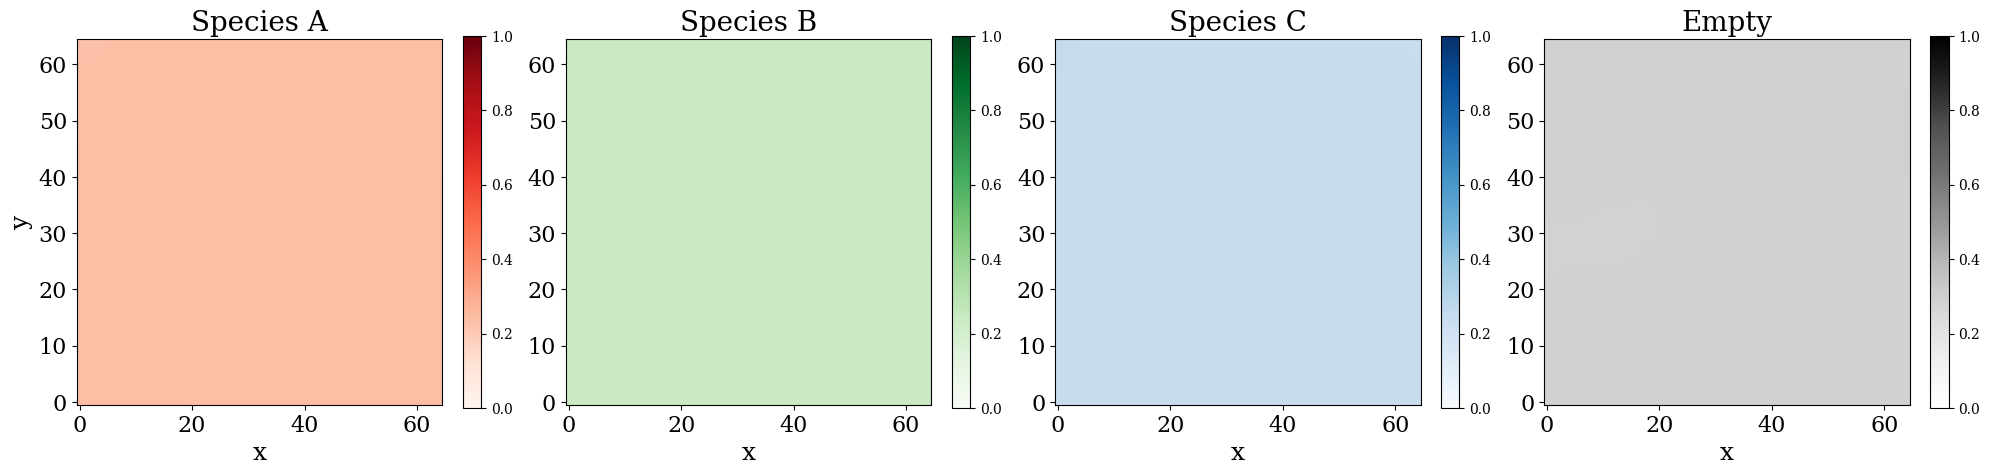

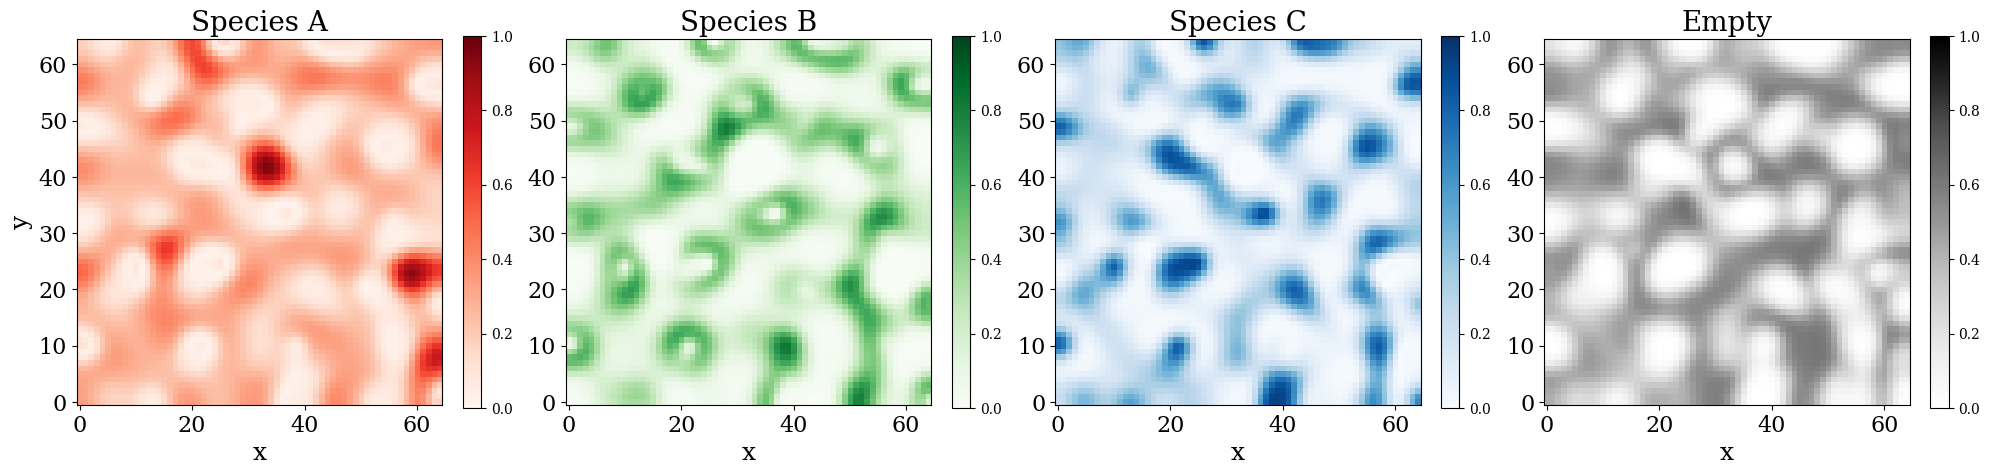

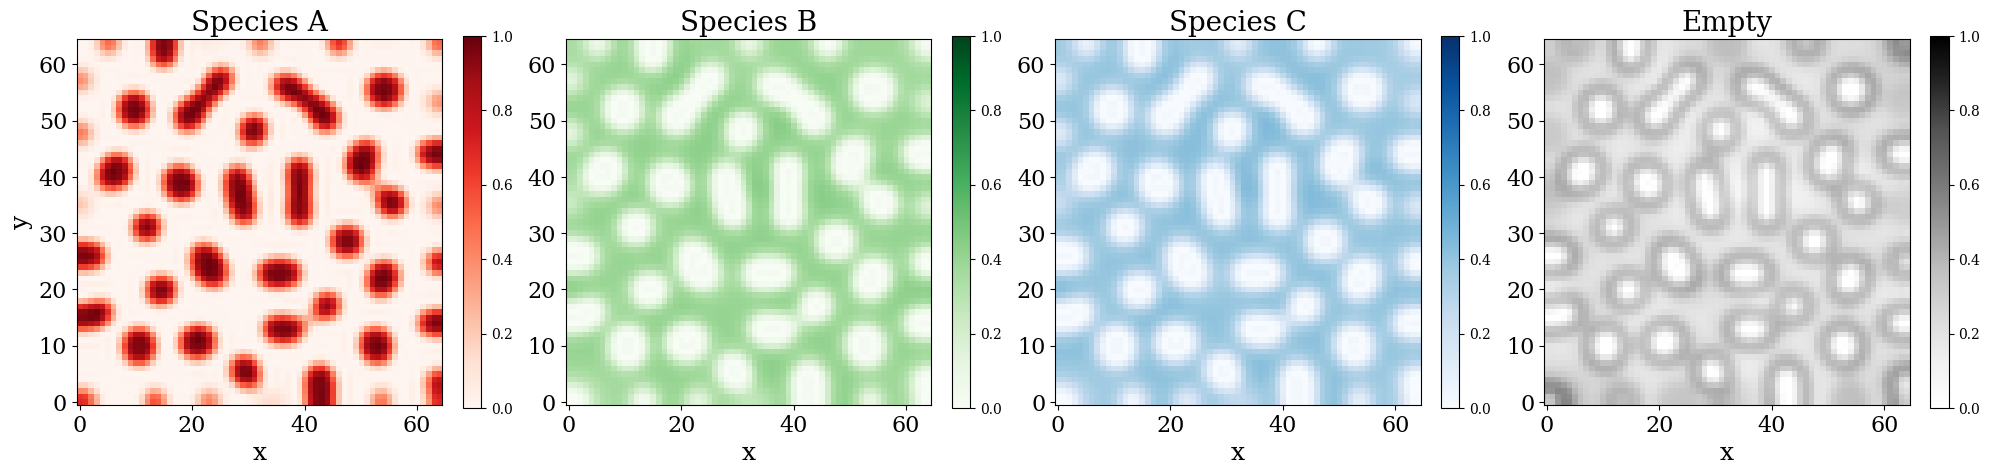

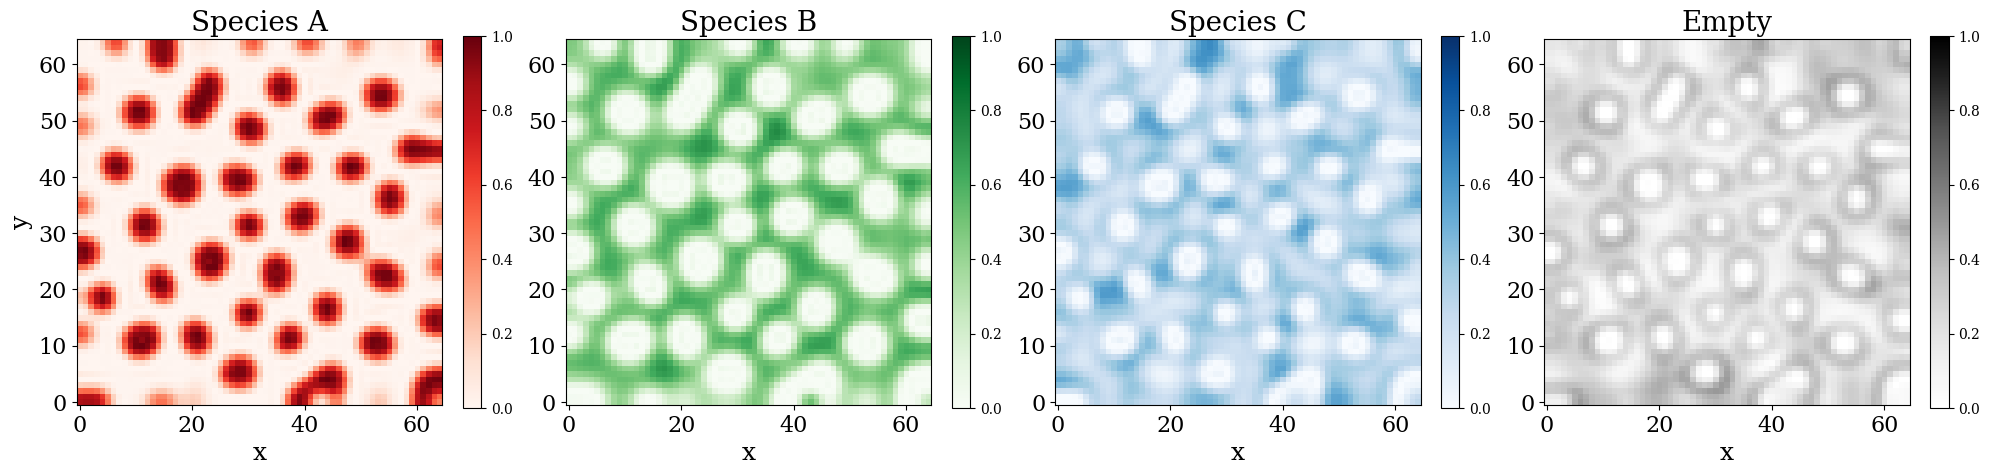

In [14]:
target_D = 0.1

for kappa_name in kappa_names:
    phi_run_final = phis_Dif[kappa_name][target_D]

    # Define parameters for the plot
    param = {
        'D': target_D * np.ones(ns),
        'kappa': kappas[kappa_names.index(kappa_name)],  # Assuming kappas is a list of kappa values
        'Gamma': Gamma,
        'nu': nu
    }

    # Plot using sim_2d.phi_plot
    sim_2d.phi_plot(
        phi_run_final,
        param,
        model="Vitelli",
        plot_2=False,
        plot_3=False,
        add_empty=True
    )

### Dissim / D plot

dict_keys(['Segregated', 'Mixed', 'Dynamic', '1 Segregated, 2 Mixed', '1 Segregated, 2 Dynamic'])


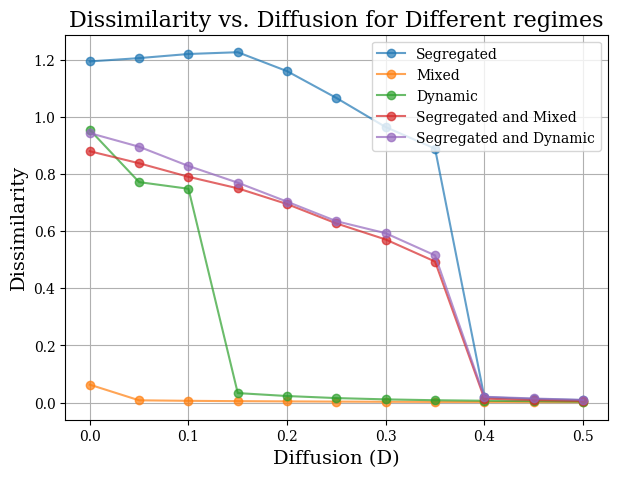

In [15]:
from re import escape


titles_regimes = ["Segregated", "Mixed", "Dynamic", "Segregated and Mixed", "Segregated and Dynamic"]

print(phis_Dif.keys())

# Initialize the plot
plt.figure(figsize=(7, 5))

# For each kappa, compute dissimilarity for all Ds and plot
for i,kappa_name in enumerate(phis_Dif):
    Ds_for_kappa = sorted(phis_Dif[kappa_name].keys())
    dissimilarities = []
    for D in Ds_for_kappa:
        phi_run_final = phis_Dif[kappa_name][D]
        dissim = fhd.dissimilarity(phi_run_final)  # Compute dissimilarity
        dissimilarities.append(dissim)
    if i < 5:
        # Plot the line for this kappa
        plt.plot(Ds_for_kappa, dissimilarities, marker='o', label=titles_regimes[i], alpha=0.7)

# Add labels and legend
plt.xlabel("Diffusion (D)", fontsize=ax_size)
plt.ylabel("Dissimilarity", fontsize=ax_size)
plt.title("Dissimilarity vs. Diffusion for Different regimes", fontsize=title_size)
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

# Gamma

In [16]:
nu = np.zeros((ns,ns,ns))
D = 0.1*np.ones(ns) 
dt = 0.005

Gammas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]

# nsteps = 100000
# nsteps = 10000
noise = 0
frames = 100
phis_gamma = defaultdict(dict)

tot = len(kappas) * len(Gammas)
sim_count = 0

for i, kappa in enumerate(kappas):
    for Gamma in Gammas:
        param_gamma = {'D': D, 'kappa': kappa, 'Gamma': Gamma*np.eye(ns), 'nu': nu}
        st = time.time()
        phi_run = sim_2d.run_until_converged(phi_init, param_gamma, dt, noise, frames, model = "Vitelli", verbatum=False)
        et = time.time()
        print(f"Simulation {kappa_names[i]}, Gamma = {Gamma}: ran in t = {et-st:.6f} seconds ({sim_count}/{tot})")
        phis_gamma[kappa_names[i]][Gamma] = phi_run[:, -1]
        sim_count += 1
    print(f"Completed simulations for {kappa_names[i]}")


Simulation Segregated, Gamma = 0.1: ran in t = 17.358641 seconds (0/100)
Simulation Segregated, Gamma = 0.2: ran in t = 19.443783 seconds (1/100)
Simulation Segregated, Gamma = 0.3: ran in t = 21.428688 seconds (2/100)
Simulation Segregated, Gamma = 0.4: ran in t = 31.584105 seconds (3/100)
Simulation Segregated, Gamma = 0.5: ran in t = 31.365652 seconds (4/100)
Simulation Segregated, Gamma = 0.6: ran in t = 30.464250 seconds (5/100)
Simulation Segregated, Gamma = 0.7: ran in t = 35.044662 seconds (6/100)
Simulation Segregated, Gamma = 0.8: ran in t = 35.979459 seconds (7/100)
Simulation Segregated, Gamma = 0.9: ran in t = 38.751497 seconds (8/100)
Simulation Segregated, Gamma = 1.0: ran in t = 42.417985 seconds (9/100)
Simulation Segregated, Gamma = 1.1: ran in t = 47.314234 seconds (10/100)
Simulation Segregated, Gamma = 1.2: ran in t = 49.382686 seconds (11/100)
Simulation Segregated, Gamma = 1.3: ran in t = 51.428689 seconds (12/100)
Simulation Segregated, Gamma = 1.4: ran in t = 5

### Snapshots

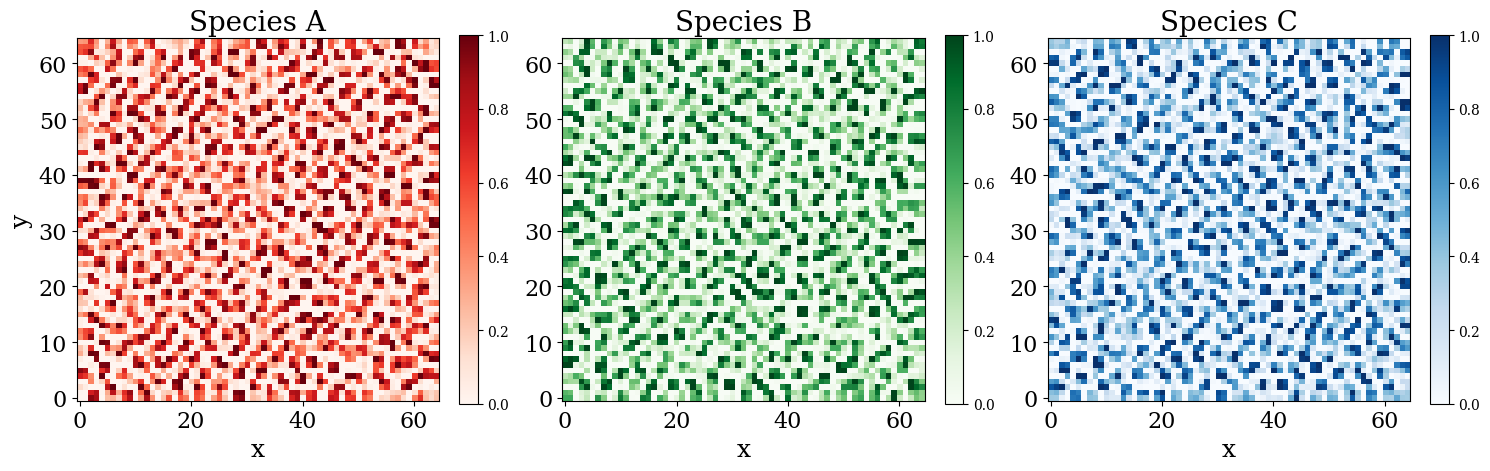

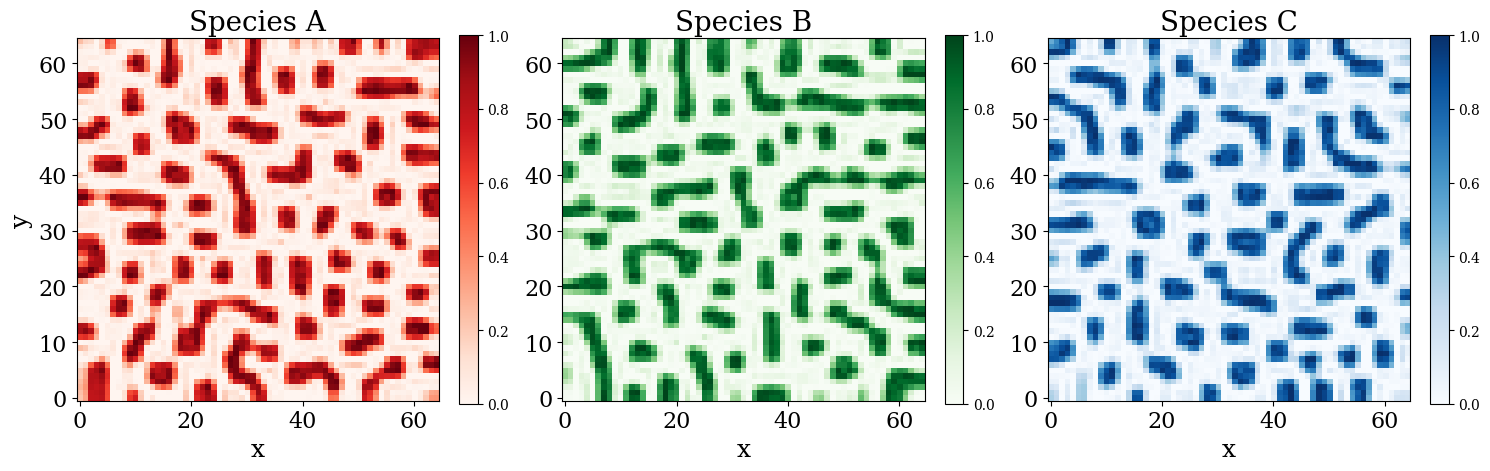

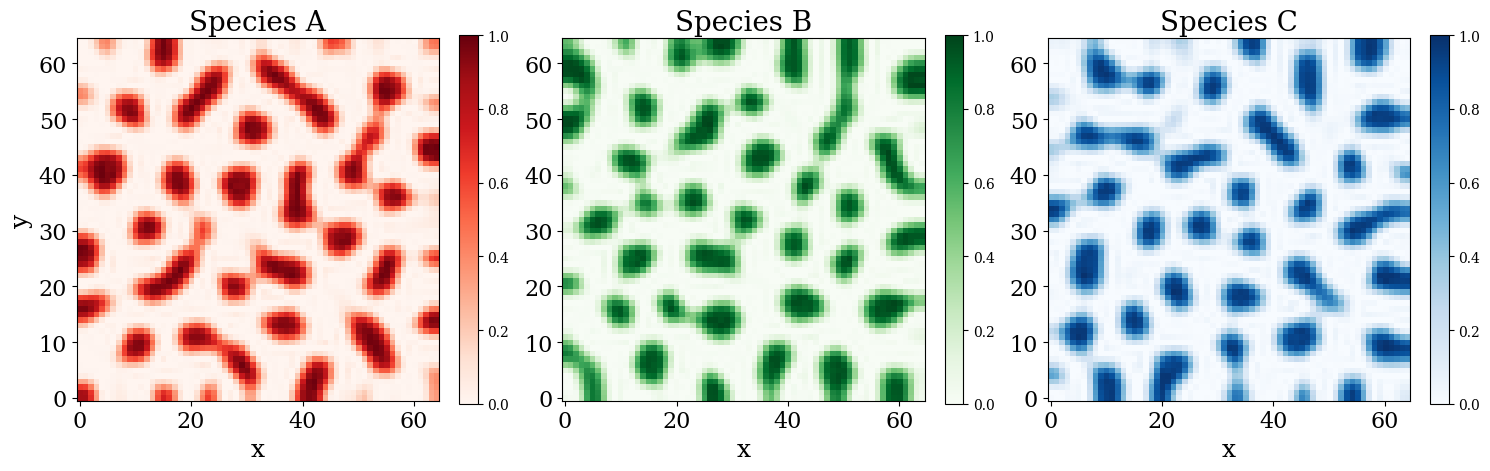

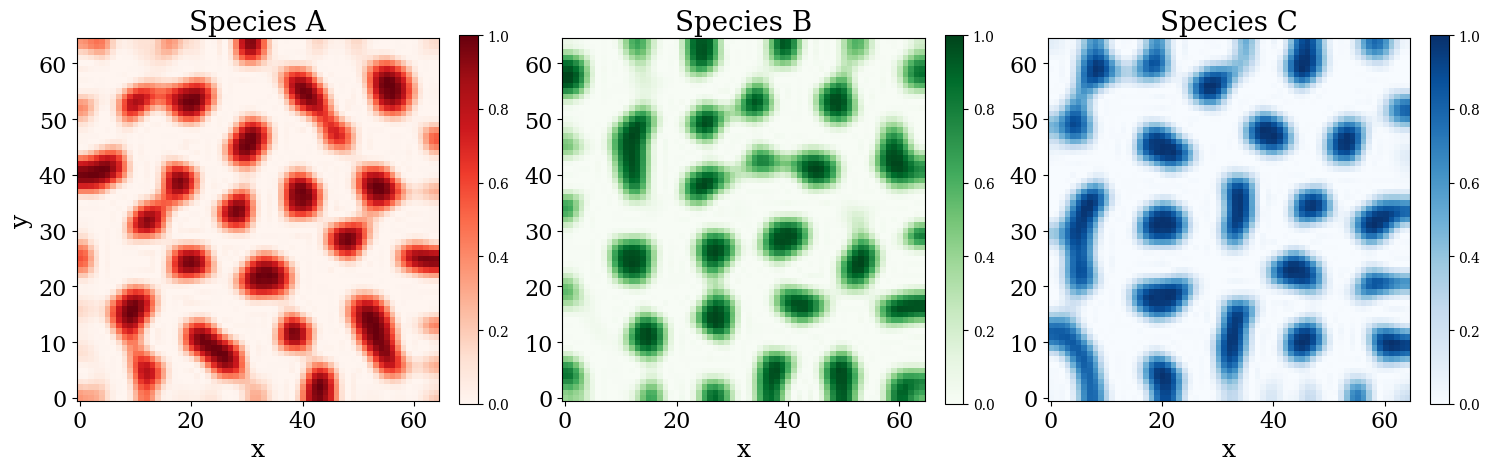

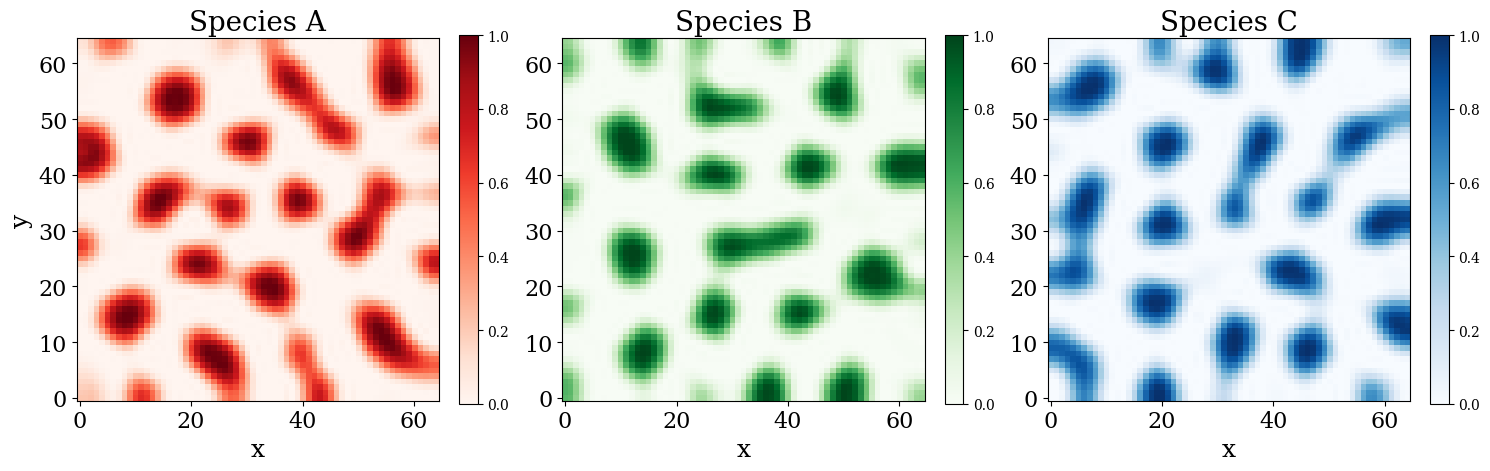

In [25]:
target_D = 0.1

Gammas_plot = [0.1, 0.5, 1.0, 1.5, 2.0]

for Gamma in Gammas_plot:
    phi_run_final = phis_gamma["Segregated"][Gamma]

    # Define parameters for the plot
    param = {
        'D': D,
        'kappa': kappa_segregated,  # Assuming kappas is a list of kappa values
        'Gamma': Gamma,
        'nu': nu
    }
    sim_2d.phi_plot(
        phi_run_final,
        param,
        model="Vitelli",
        plot_2=False,
        plot_3=False,
        # add_empty=True
    )

### Plot

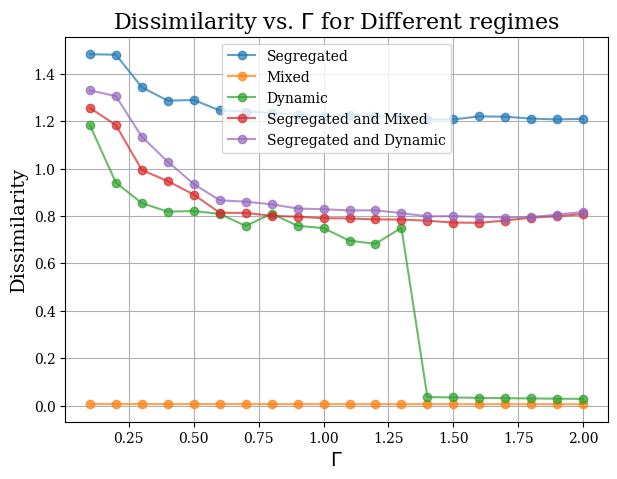

In [22]:
titles_regimes = ["Segregated", "Mixed", "Dynamic", "Segregated and Mixed", "Segregated and Dynamic"]

# print(phis_Dif.keys())

# Initialize the plot
plt.figure(figsize=(7, 5))

# For each kappa, compute dissimilarity for all Ds and plot
for i,kappa_name in enumerate(phis_gamma):
    Gamma_for_kappa = sorted(phis_gamma[kappa_name].keys())
    dissimilarities = []
    for Gamma in Gamma_for_kappa:
        phi_run_final = phis_gamma[kappa_name][Gamma]
        dissim = fhd.dissimilarity(phi_run_final)  # Compute dissimilarity
        dissimilarities.append(dissim)
    if i < 5:
        # Plot the line for this kappa
        plt.plot(Gamma_for_kappa, dissimilarities, marker='o', label=titles_regimes[i], alpha=0.7)

# Add labels and legend
plt.xlabel(r"$\Gamma$", fontsize=ax_size)
plt.ylabel("Dissimilarity", fontsize=ax_size)
plt.title(r"Dissimilarity vs. $\Gamma$ for Different regimes", fontsize=title_size)
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

# Quadratic utility

In [19]:
nus_a = np.zeros((ns,ns,ns))
nus_b = np.zeros((ns,ns,ns))
nus_c = np.zeros((ns,ns,ns))

nu_a = np.array([
    [0, 1, 0],    
    [1, -1, -1],   
    [0, -1, 0]    
])

nu_b = np.array([
    [-1, 1, 1],    
    [1, -1, 1],   
    [1, 1, -1]    
])

nu_c = np.array([
    [-1, 0, 1],    
    [0, 0, 0],   
    [1, 0, 0]    
])

nus_a[0, :, :] = nu_a
nus_b[1, :, :] = nu_b
nus_c[2, :, :] = nu_c

# Create the list
nus = [nus_a, nus_b, nus_c]
nu_names = ["nu_a", "nu_b", "nu_c"]

In [32]:
# nu = np.zeros((ns,ns,ns))
D = 0.1*np.ones(ns) 
dt = 0.005
Gamma = np.eye(ns) # Utility nabla^3 term coefficient

# nsteps = 100000
nsteps = 10000
noise = 0
frames = 100
phis_nu = defaultdict(dict)

tot = len(kappas) * len(nus)
sim_count = 1

for i, kappa in enumerate(kappas):
    for jnu, nu in enumerate(nus):
        param_nu = {'D': D, 'kappa': kappa, 'Gamma': Gamma, 'nu': nu}
        st = time.time()
        phi_run = sim_2d.run_until_converged(phi_init, param_nu, dt, noise, frames, model = "Vitelli", verbatum=False)
        et = time.time()
        print(f"Simulation {kappa_names[i]}, {nu_names[jnu]}: ran in t = {et-st:.6f} seconds ({sim_count}/{tot})")
        phis_nu[kappa_names[i]][nu_names[jnu]] = phi_run[:, -1]
        sim_count += 1
    print(f"Completed simulations for {kappa_names[i]}")


Simulation Segregated, nu_a: ran in t = 48.616928 seconds (1/15)
Simulation Segregated, nu_b: ran in t = 51.532624 seconds (2/15)
Simulation Segregated, nu_c: ran in t = 57.029025 seconds (3/15)
Completed simulations for Segregated
Simulation Mixed, nu_a: ran in t = 63.809511 seconds (4/15)
Simulation Mixed, nu_b: ran in t = 141.940263 seconds (5/15)
Simulation Mixed, nu_c: ran in t = 104.679677 seconds (6/15)
Completed simulations for Mixed
Simulation Dynamic, nu_a: ran in t = 85.032316 seconds (7/15)
Simulation Dynamic, nu_b: ran in t = 142.185580 seconds (8/15)
Simulation Dynamic, nu_c: ran in t = 131.426551 seconds (9/15)
Completed simulations for Dynamic
Simulation 1 Segregated, 2 Mixed, nu_a: ran in t = 46.416097 seconds (10/15)
Simulation 1 Segregated, 2 Mixed, nu_b: ran in t = 49.137097 seconds (11/15)
Simulation 1 Segregated, 2 Mixed, nu_c: ran in t = 46.619082 seconds (12/15)
Completed simulations for 1 Segregated, 2 Mixed
Simulation 1 Segregated, 2 Dynamic, nu_a: ran in t = 

## Snapshots


Plotting for Segregated with nu_a


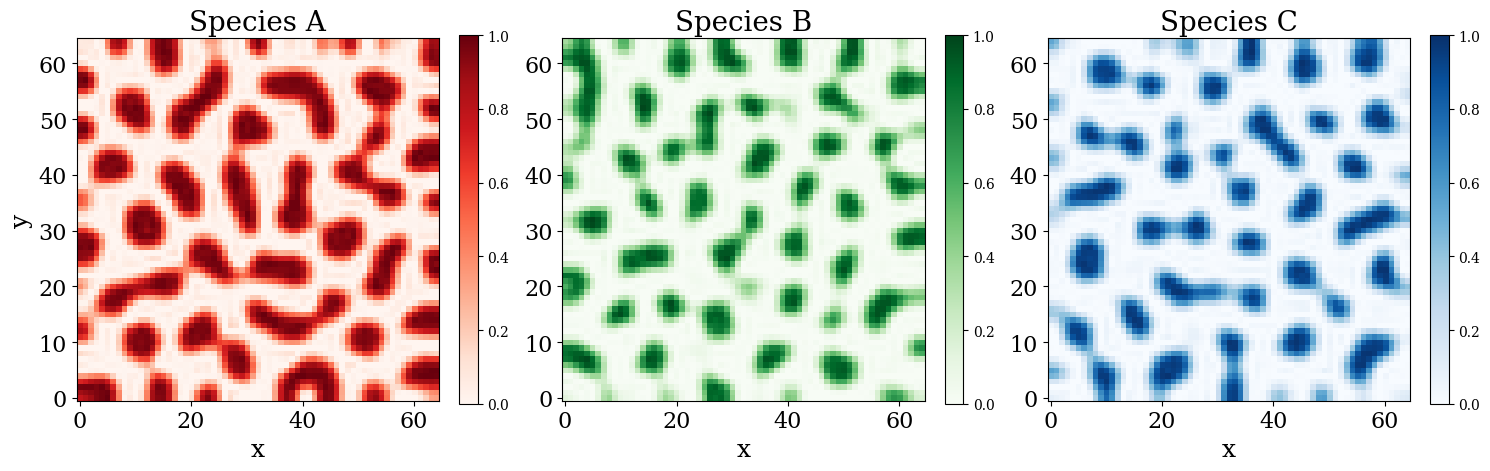

Plotting for Segregated with nu_b


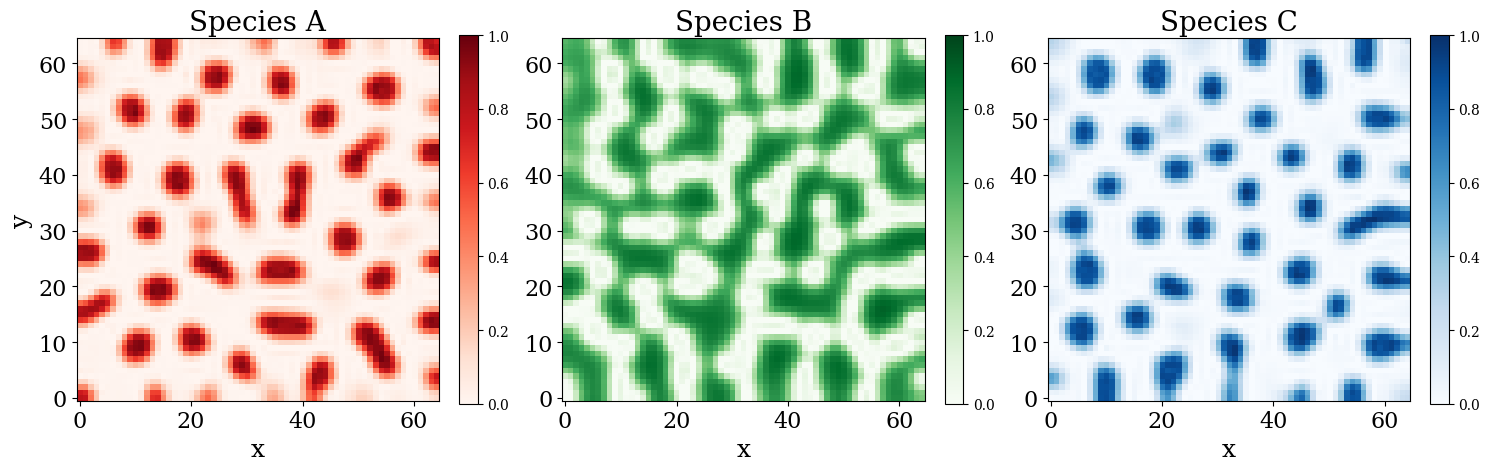

Plotting for Segregated with nu_c


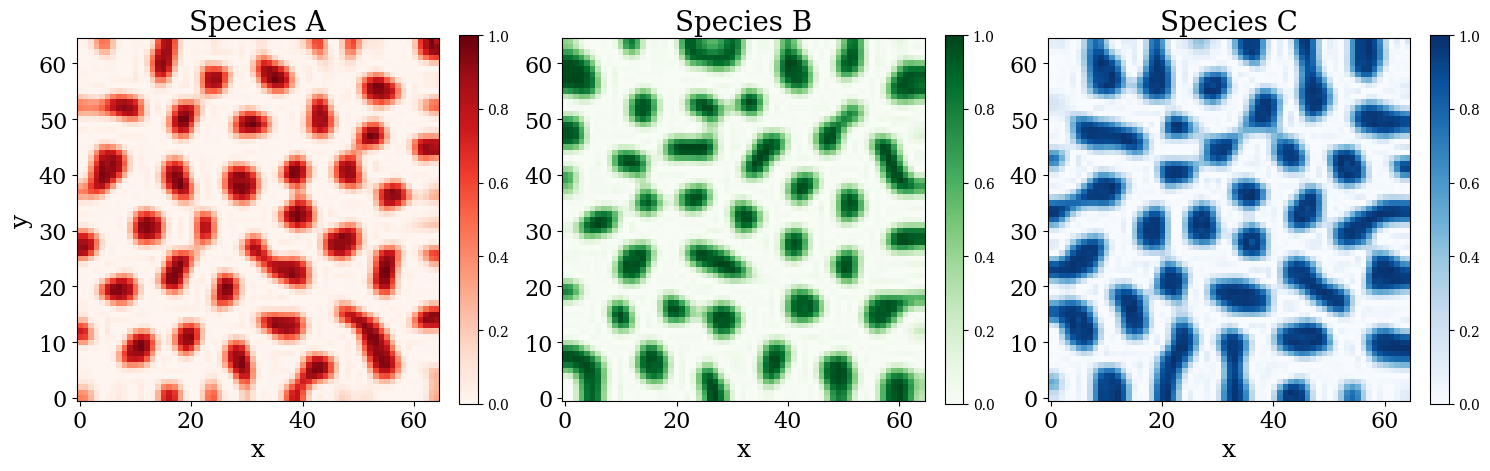

Plotting for Mixed with nu_a


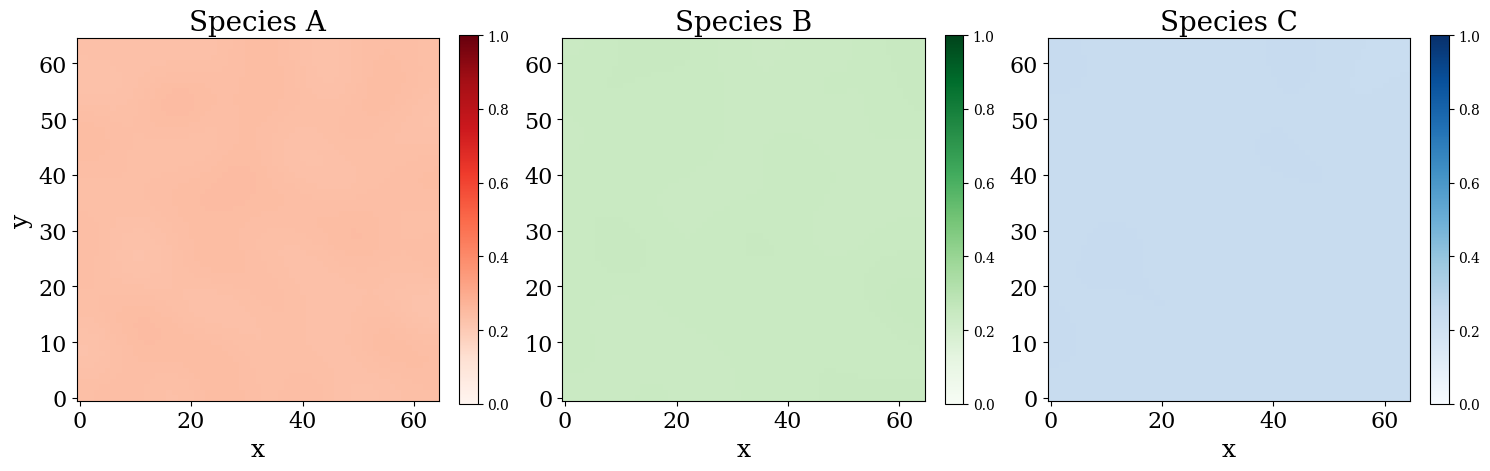

Plotting for Mixed with nu_b


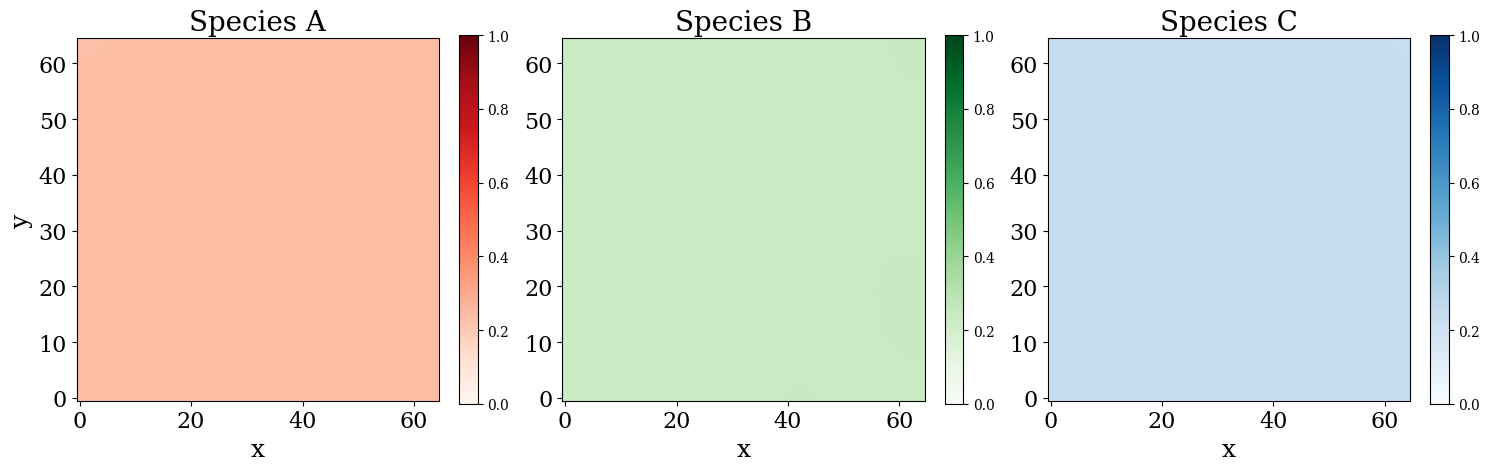

Plotting for Mixed with nu_c


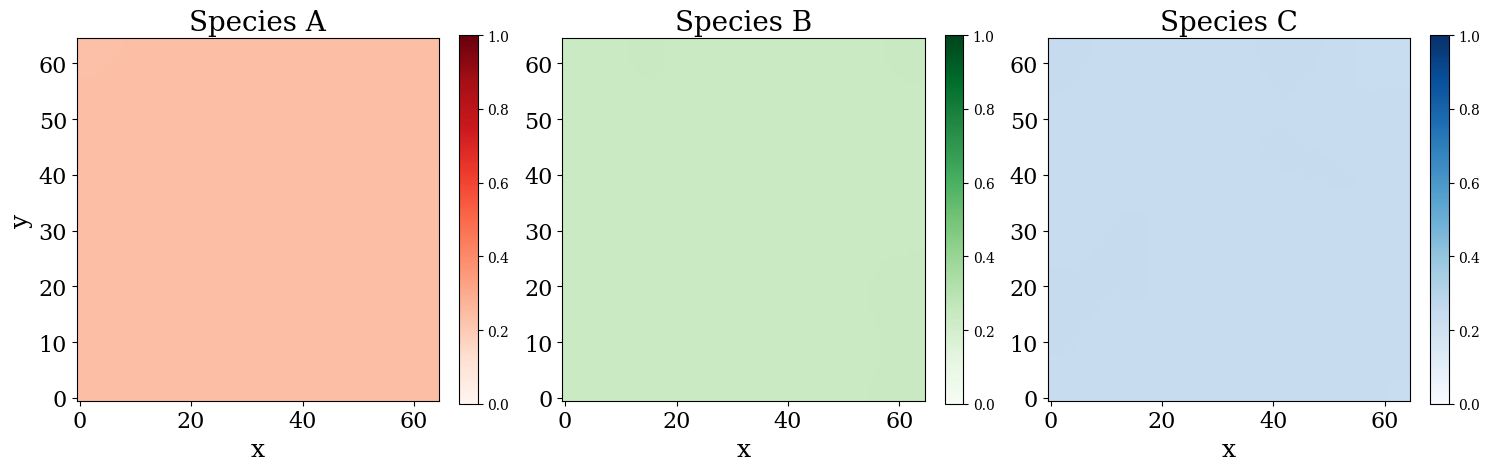

Plotting for Dynamic with nu_a


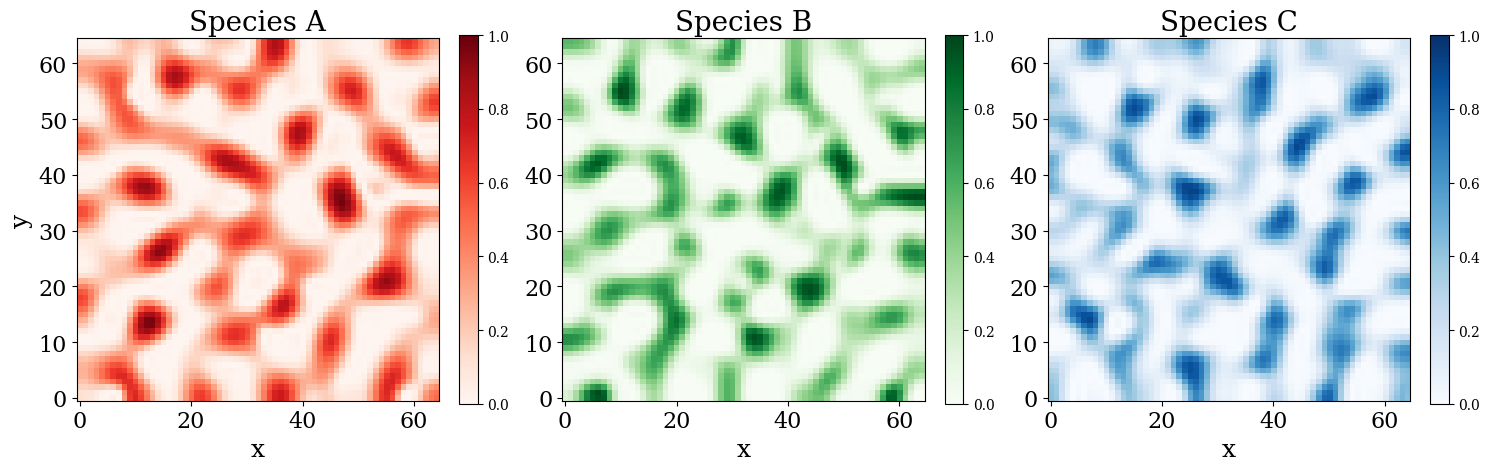

Plotting for Dynamic with nu_b


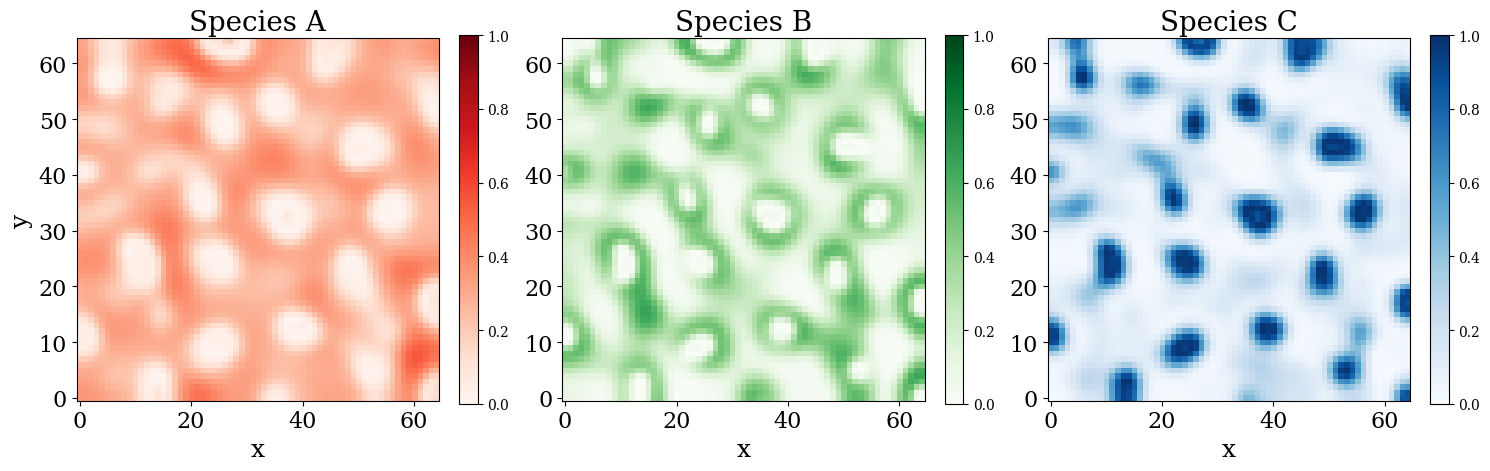

Plotting for Dynamic with nu_c


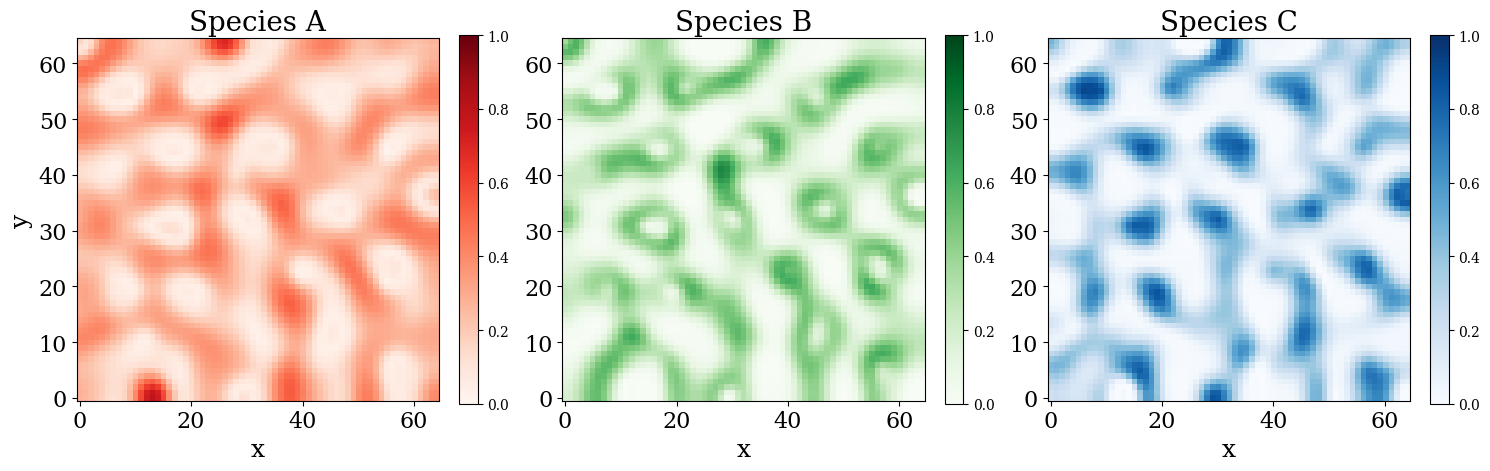

Plotting for 1 Segregated, 2 Mixed with nu_a


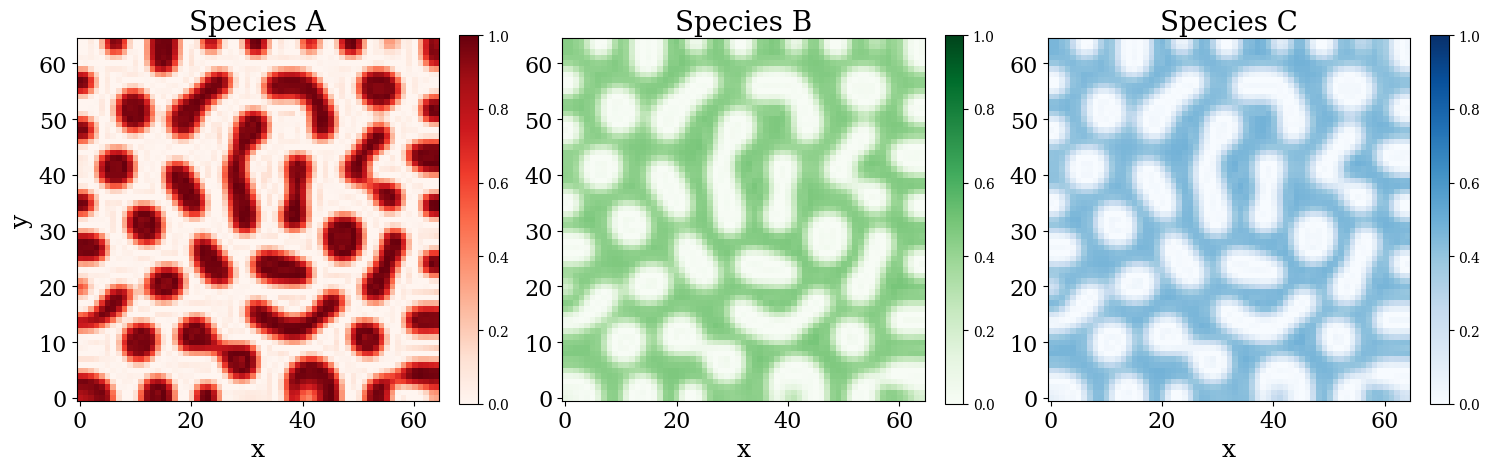

Plotting for 1 Segregated, 2 Mixed with nu_b


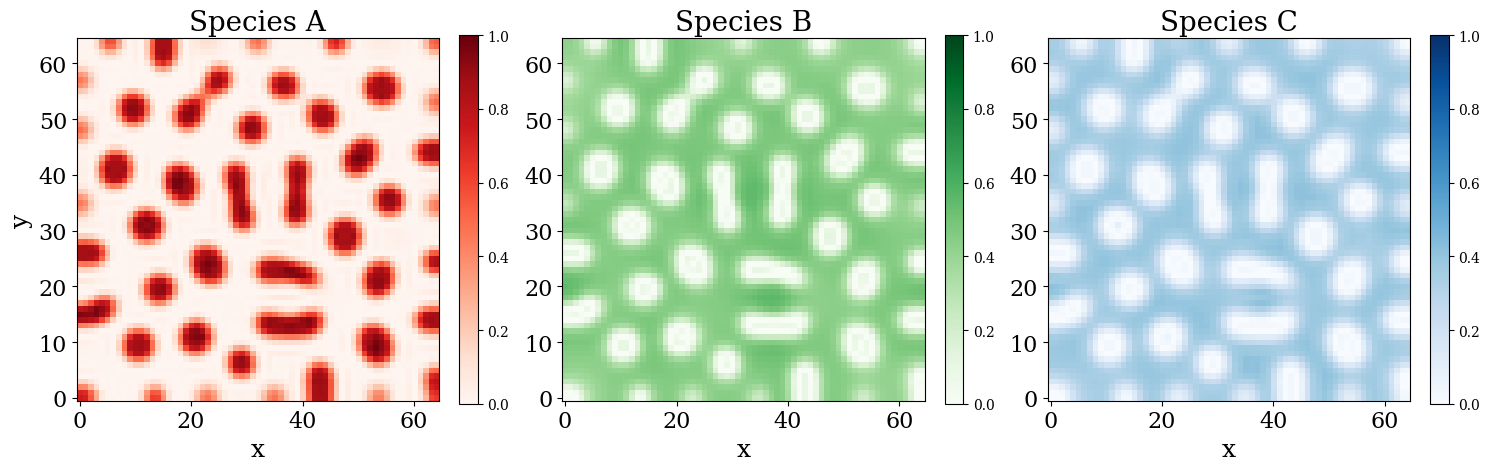

Plotting for 1 Segregated, 2 Mixed with nu_c


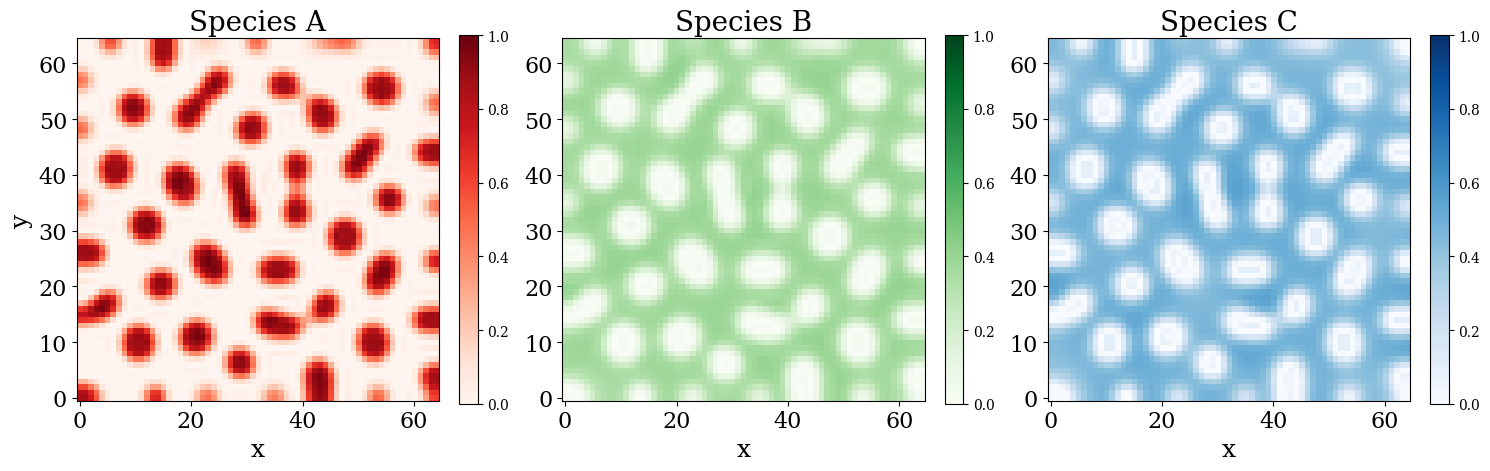

Plotting for 1 Segregated, 2 Dynamic with nu_a


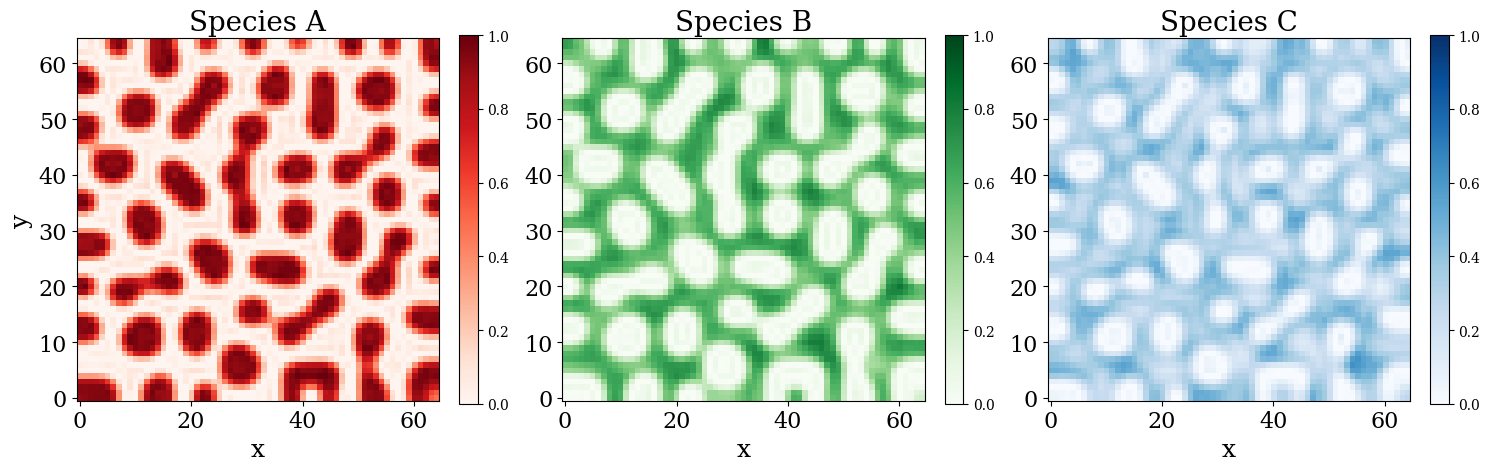

Plotting for 1 Segregated, 2 Dynamic with nu_b


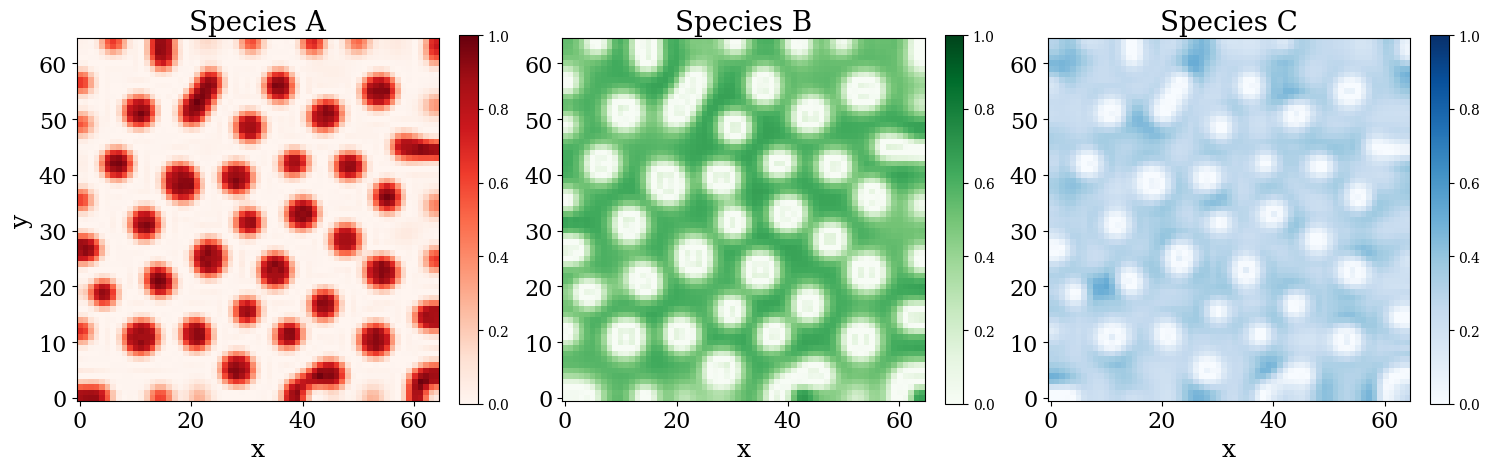

Plotting for 1 Segregated, 2 Dynamic with nu_c


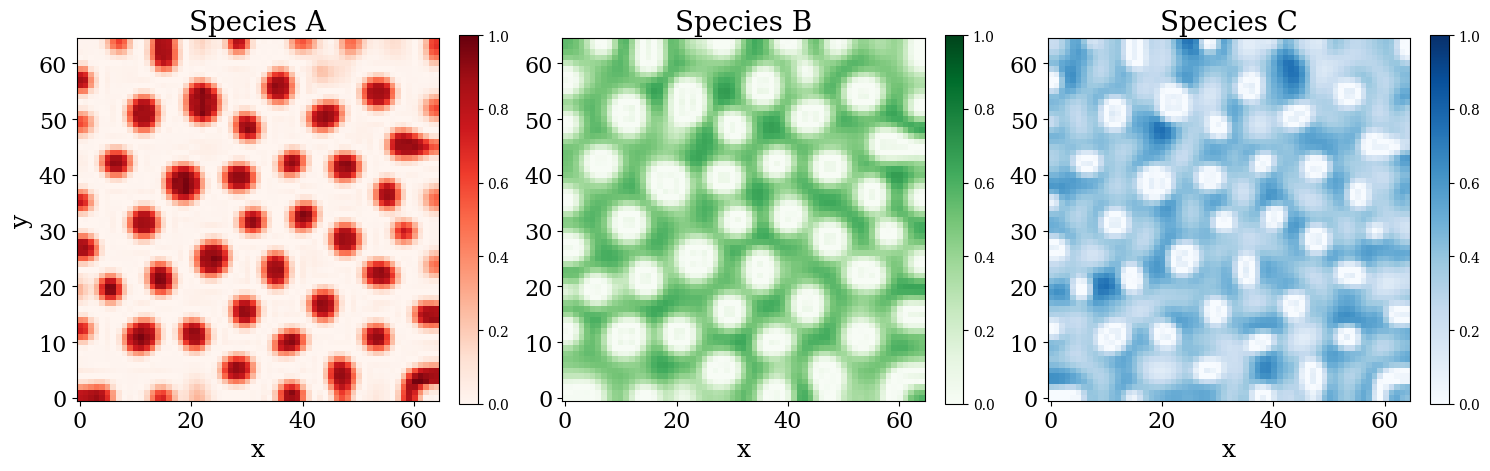

In [33]:
target_D = 0.1

for kappa_name in kappa_names:
    for nu in nu_names:
        print(f"Plotting for {kappa_name} with {nu}")
        phi_run_final = phis_nu[kappa_name][nu]

        # Define parameters for the plot
        param = {
            'D': target_D,
            'kappa': kappa_segregated,  # Assuming kappas is a list of kappa values
            'Gamma': Gamma,
            'nu': nu
        }
        sim_2d.phi_plot(
            phi_run_final,
            param,
            model="Vitelli",
            plot_2=False,
            plot_3=False,
            # add_empty=True
        )

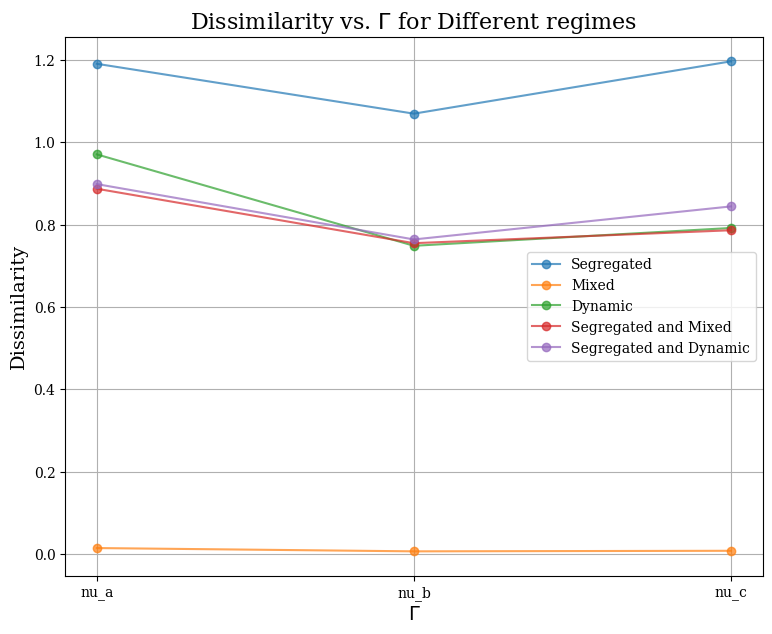

In [ ]:
titles_regimes = ["Segregated", "Mixed", "Dynamic", "Segregated and Mixed", "Segregated and Dynamic"]

# print(phis_Dif.keys())

# Initialize the plot
plt.figure(figsize=(9, 7))

# For each kappa, compute dissimilarity for all Ds and plot
for i,kappa_name in enumerate(phis_nu):
    # Gamma_for_kappa = sorted(phis_nu[kappa_name].keys())
    dissimilarities = []
    for nu in nu_names:
        phi_run_final = phis_nu[kappa_name][nu]
        dissim = fhd.dissimilarity(phi_run_final)  # Compute dissimilarity
        dissimilarities.append(dissim)
    if i < 5:
        # Plot the line for this kappa
        plt.plot(nu_names, dissimilarities, marker='o', label=titles_regimes[i], alpha=0.7)

# Add labels and legend
plt.xlabel(r"$\Gamma$", fontsize=ax_size)
plt.ylabel("Dissimilarity", fontsize=ax_size)
plt.title(r"Dissimilarity vs. $\Gamma$ for Different regimes", fontsize=title_size)
plt.legend()
plt.grid(True)

# Show the plot
plt.show()